In [1]:
!pip install gymnasium
!pip install tensorflow
!pip install matplotlib

In [2]:
import gymnasium as gym
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [3]:
env = gym.make("CartPole-v1")

state_size = env.observation_space.shape[0]

print("State Size:", state_size)

State Size: 4


In [4]:
model = tf.keras.Sequential([

    tf.keras.layers.Dense(
        24,
        activation='relu',
        input_shape=(state_size,)
    ),

    tf.keras.layers.Dense(
        24,
        activation='relu'
    ),

    tf.keras.layers.Dense(
        1,
        activation='linear'
    )
])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 24)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 745 (2.91 KB)

 Trainable params: 745 (2.91 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
state, info = env.reset()

prediction = model.predict(
    np.reshape(state, [1, state_size]),
    verbose=0
)

print("Predicted Value:", prediction)

Predicted Value: [[0.00057604]]


In [6]:
states = []
targets = []

In [7]:
episodes = 200

for episode in range(episodes):

    state, info = env.reset()

    total_reward = 0

    done = False

    while not done:

        action = env.action_space.sample()

        next_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated

        total_reward += reward

        states.append(state)

        targets.append(total_reward)

        state = next_state

print("Data Collection Finished")

Data Collection Finished


In [8]:
X = np.array(states)

y = np.array(targets)

print(X.shape)
print(y.shape)

(4327, 4)
(4327,)


In [9]:
history = model.fit(

    X,
    y,

    epochs=20,
    batch_size=32,

    verbose=1
)

Epoch 1/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 342.8049
Epoch 2/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 181.4659
Epoch 3/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 159.6075
Epoch 4/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 154.8508
Epoch 5/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 149.6138
Epoch 6/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 143.3848
Epoch 7/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 136.2702
Epoch 8/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 127.5798
Epoch 9/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 118.1453
Epoch 10/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 108.2098
Epoch 11/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 99.9417 
Epoch 12/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 94.8278
Epoch 13/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 91.8995
Epoch 14/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 90.3581
Epoch 15/20
136/136 ━━━━━━━━━━━━

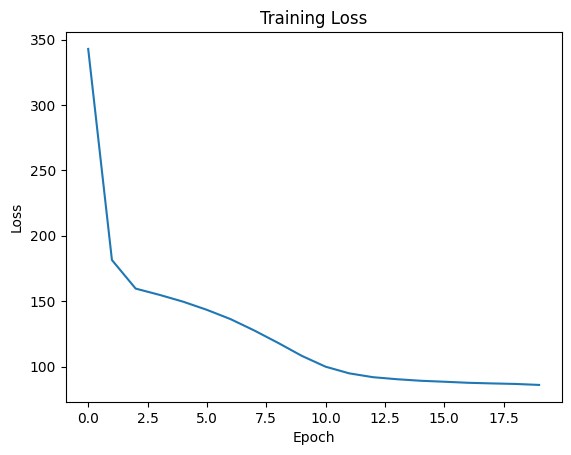

In [10]:
plt.plot(history.history['loss'])

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.show()